In [1]:
import sys
import importlib.util
from pathlib import Path

# Project root (run from repo root or from notebooks/)
ROOT = Path.cwd().parent.parent if Path.cwd().name == "notebooks" else Path.cwd()

# Load focus_groups directly from file to avoid conflict with stdlib 'code' module
_focus_groups_path = ROOT / "code" / "libs" / "utils" / "focus_groups.py"
_spec = importlib.util.spec_from_file_location("focus_groups", _focus_groups_path)
focus_groups = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(focus_groups)

import seaborn as sns

In [2]:
sns.set_context('paper', font_scale=1.5)

In [3]:
config_path = ROOT / "config" / "focus" / "focus.yaml"
data_dir = ROOT / "data"
data = focus_groups.load_focus_data(config_path, data_dir)

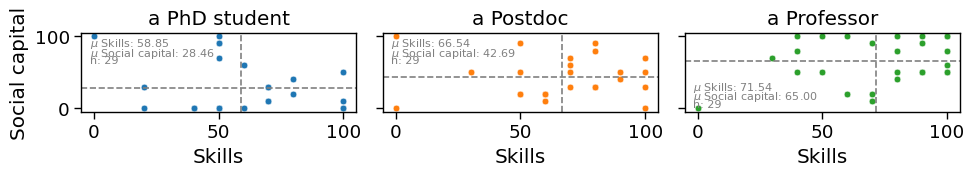

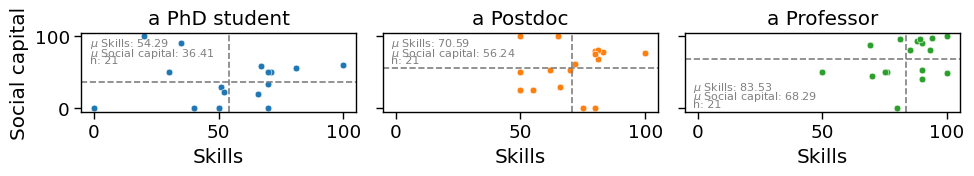

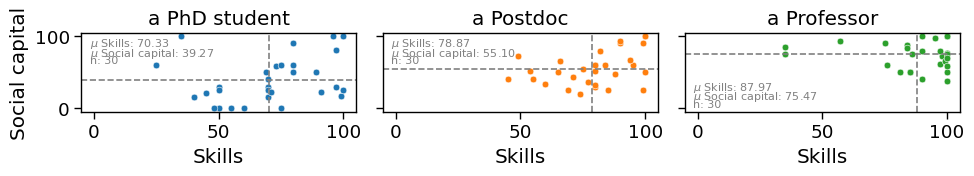

In [4]:
# Minimum requirements: one plot per focus group
focus_groups.plot_minimum_threshold_answers(data[1]["df"])
focus_groups.plot_minimum_threshold_answers(data[2]["df"])
focus_groups.plot_minimum_threshold_answers(data[3]["df"])

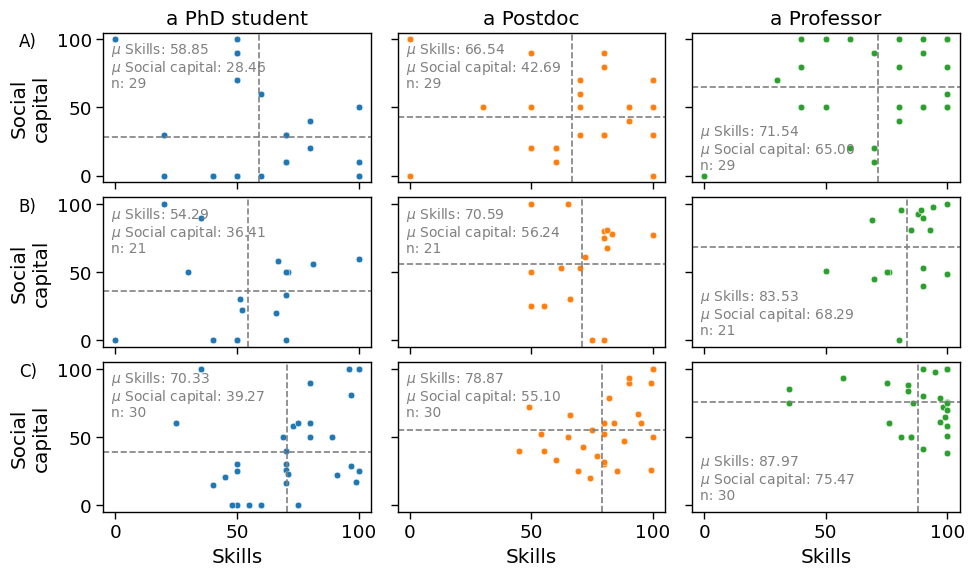

In [5]:
# All groups in one figure; save to PDF for paper
fn = ROOT / "results" / "plots" / "focus_requirements_by_role.pdf"
fn.parent.mkdir(parents=True, exist_ok=True)
focus_groups.plot_minimum_threshold_answers_all(data, fn=fn, row_labels=True)

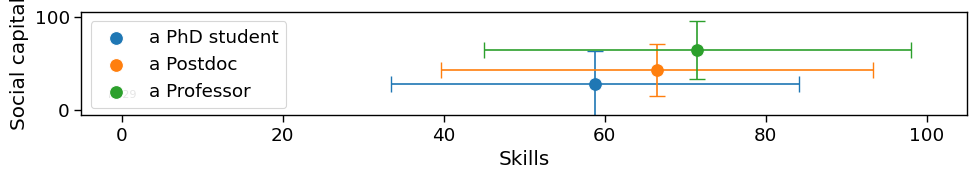

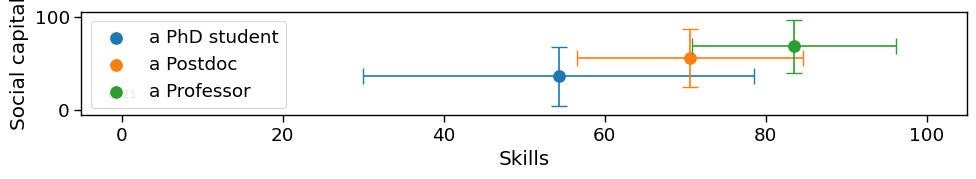

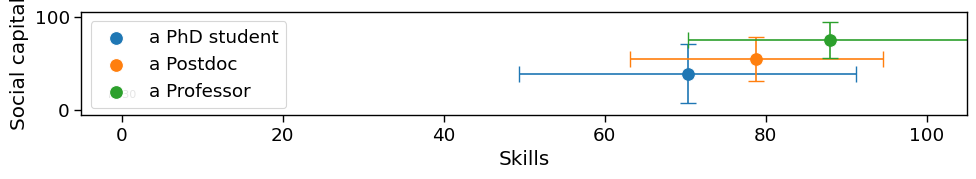

In [6]:
# Aggregate view (means only) per group
focus_groups.plot_minimum_threshold_answers(data[1]["df"], aggregate=True)
focus_groups.plot_minimum_threshold_answers(data[2]["df"], aggregate=True)
focus_groups.plot_minimum_threshold_answers(data[3]["df"], aggregate=True)


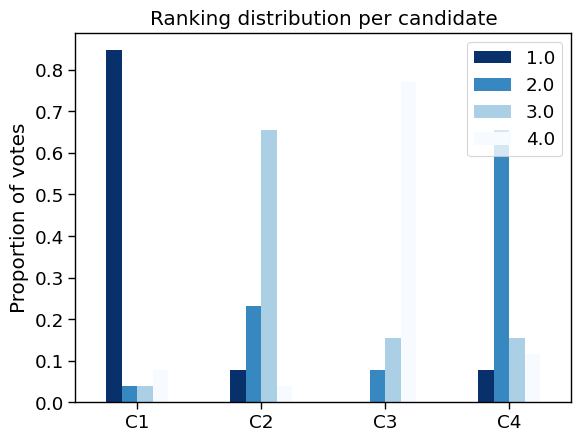

In [7]:
# Ranking task: Vienna group (group_id=1)
rank_counts, rank_percent = focus_groups.get_ranking_stats(data, 
                                                           group_id=1, 
                                                           complete_only=True)
focus_groups.plot_ranking_distribution(rank_percent)

In [8]:
display(rank_counts)
display(rank_percent)

,C1,C2,C3,C4
1.0,22,2,0.0,2
2.0,1,6,2.0,17
3.0,1,17,4.0,4
4.0,2,1,20.0,3


,C1,C2,C3,C4
1.0,0.846154,0.076923,0.000000,0.076923
2.0,0.038462,0.230769,0.076923,0.653846
3.0,0.038462,0.653846,0.153846,0.153846
4.0,0.076923,0.038462,0.769231,0.115385


In [9]:
# Data summary
for gid, obj in data.items():
    print(gid, obj["n"], obj["df"].shape, obj["where"])

1 29 (29, 64) CSH-Talk
2 21 (21, 37) Seminar at ANETI Lab
3 30 (30, 35) CS-Talks \#15 at TUGraz
